# IKENGA — UI-PARITY FINAL NOTEBOOK

**Purpose:** Canonical multi-layer analysis matching the production Market View UI exactly before frontend handoff.

Pipeline:
1. **Global source** — run 1w + 1d, pick most confirmed legs (tie-break = parameterized)
2. **Prime internal** — last confirmed global impulse → slice 4h/1h/30m, pick most legs
3. **Candidate internal** — candidate start→extreme → slice 4h/1h/30m, pick most legs
4. **State machine** — `(structure_state, choch_state, bos_state)` per layer
5. **Cross-timeframe projection** — same canonical overlays on every display-TF panel

Edit algorithms in `sandbox/algorithms/`, not `src/`.

In [26]:
# ============================================================
# CELL 1: SETUP AND IMPORTS
# ============================================================
import sys
from pathlib import Path

ROOT    = Path("..").resolve()
SANDBOX = ROOT / "sandbox" / "algorithms"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SANDBOX) not in sys.path:
    sys.path.insert(0, str(SANDBOX))

# Import FROM SANDBOX — these override live src/ imports
from trend_id import identify_trend, compute_internal_structure
from choch_zone import compute_choch_zone, annotate_legs_with_choch_zones
from structure_levels import (
    compute_all_structure_levels,
    annotate_internal_bos_classifications,
    classify_bos_events,
    collapse_false_break_impulses,
    extract_false_break_impulses,
    compute_last_impulse_internal_choch_zone,
)
from structural_walker import walk_structure
from filter_defaults import SCAN_AND_ANALYSIS_FILTER_DEFAULTS

# DB and candle access — always from live src/
from src.db.session import SessionLocal
from src.db.models import MonitoredSetup
from src.cache.candle_store import get_candles

print("✓ Sandbox imports OK")
print(f"✓ Algorithm source: {SANDBOX}")

✓ Sandbox imports OK
✓ Algorithm source: C:\Users\vokor\Documents\Projects\chronos-ai\sandbox\algorithms


In [27]:
# ============================================================
# CELL 2: CONFIGURATION  — edit values here
# ============================================================

SYMBOL = "1HZ90V"

# ── Global source selection ────────────────────────────────────────────────────
GLOBAL_SOURCE_TFS = ["1w", "1d"]  # both evaluated; pick by most confirmed legs
GLOBAL_TIEBREAK   = "daily"        # "daily" or "weekly"  — flips preference on tie

# ── Prime impulse internal structure ──────────────────────────────────────────
PRIME_INTERNAL_TFS = ["4h", "1h", "30m"]  # sliced from last global impulse range

# ── Candidate impulse internal analysis ───────────────────────────────────────
CANDIDATE_INTERNAL_TFS = ["4h", "1h", "30m"]  # sliced from candidate start→extreme

# ── Display panels ────────────────────────────────────────────────────────────
# Every panel receives the same canonical overlays projected onto its candles.
DISPLAY_TIMEFRAMES = ["1d", "4h", "1h", "30m"]

# ── Drawing toggles ───────────────────────────────────────────────────────────
SHOW_GLOBAL    = True
SHOW_PRIME     = True
SHOW_WALKER    = True
SHOW_CANDIDATE = True

# ── Swing detection ───────────────────────────────────────────────────────────
MIN_SWING_CANDLES             = 3
TREND_CONFIRMATION_PCT        = 0.03
WALKER_TREND_CONFIRMATION_PCT = 0.002

# ── Sequence / BOS controls ───────────────────────────────────────────────────
IMPULSE_SELECTION_MODE        = "largest_score"
ENFORCE_IMPULSE_BOS           = True
MIN_BOS_BREAK_RATIO           = 0.0
IMPULSE_TOP_N                 = 2
FALSE_BREAK_RETRACE_RATIO     = 0.70
APPLY_FALSE_BREAK_CLEANER     = True
FALSE_IMPULSE_MAX_ITERATIONS  = 20

# ── Trend filters ─────────────────────────────────────────────────────────────
USE_PARENT_RELATIVE_FILTER = True
MIN_IMPULSE_PARENT_RATIO   = 0.02
USE_MOMENTUM_FILTER        = True
MIN_MOMENTUM_RATIO         = 0.01
USE_DOMINANCE_FILTER       = True
MIN_DOMINANCE_RATIO        = 0.05

# ── Filter config dict ────────────────────────────────────────────────────────
FILTER_CONFIG = dict(SCAN_AND_ANALYSIS_FILTER_DEFAULTS)
FILTER_CONFIG.update({
    "min_swing_candles":          MIN_SWING_CANDLES,
    "trend_confirmation_pct":     TREND_CONFIRMATION_PCT,
    "impulse_selection_mode":     IMPULSE_SELECTION_MODE,
    "enforce_impulse_bos":        ENFORCE_IMPULSE_BOS,
    "min_bos_break_ratio":        MIN_BOS_BREAK_RATIO,
    "impulse_top_n":              IMPULSE_TOP_N,
    "use_parent_relative_filter": USE_PARENT_RELATIVE_FILTER,
    "min_impulse_parent_ratio":   MIN_IMPULSE_PARENT_RATIO,
    "use_momentum_filter":        USE_MOMENTUM_FILTER,
    "min_momentum_ratio":         MIN_MOMENTUM_RATIO,
    "use_dominance_filter":       USE_DOMINANCE_FILTER,
    "min_dominance_ratio":        MIN_DOMINANCE_RATIO,
})

# ── Color palette — exact frontend match ──────────────────────────────────────
# Source: frontend/src/lib/structure-colors.ts + candle-chart.tsx constants
COLORS = {
    "bg":                "#111318",
    "grid":              "#1C1E24",
    "text":              "#787B86",
    "candle_up":         "#4CAF7D",
    "candle_down":       "#E05A5A",
    "global_imp":        "#26A69A",
    "global_ret":        "#EF5350",
    "prime_leg":         "#FFFFFF",
    "candidate_imp":     "#8EE36B",
    "candidate_ret":     "#5FCB7A",
    "candidate_line":    "#FFFFFF",
    "candidate_extreme": "#FFD166",
    "amber":             "#F5A623",   # CHART_GLOBAL_CHOCH_AMBER
    "ichoch":            "#4DD0E1",   # CHART_INTERNAL_CHOCH_TEAL
    "cand_choch":        "#FF9800",   # candidate prime CHoCH (orange)
    "depth_1":           "#2196F3",   # CHART_CHOCH_DEPTH1_BLUE
    "depth_2":           "#4CAF50",
    "depth_3":           "#9C27B0",
    "bos_true":          "#00C853",
    "bos_false":         "#D50000",
    "bos_pending":       "#9E9E9E",
    "bos_draw":          "#1E90FF",
    "walker_first_move": "#FFD166",
    "source_label":      "#B0BEC5",
}
DEPTH_COLORS = {1: COLORS["depth_1"], 2: COLORS["depth_2"], 3: COLORS["depth_3"]}

# Resolve tiebreak TF key from policy name
TIEBREAK_MAP = {"daily": "1d", "weekly": "1w"}

print(f"Symbol:              {SYMBOL}")
print(f"Global source TFs:   {GLOBAL_SOURCE_TFS}  tiebreak={GLOBAL_TIEBREAK}")
print(f"Prime internal TFs:  {PRIME_INTERNAL_TFS}")
print(f"Candidate TFs:       {CANDIDATE_INTERNAL_TFS}")
print(f"Display panels:      {DISPLAY_TIMEFRAMES}")
print(f"False-break ratio:   {FALSE_BREAK_RETRACE_RATIO}  cleaner={APPLY_FALSE_BREAK_CLEANER}")

Symbol:              1HZ90V
Global source TFs:   ['1w', '1d']  tiebreak=daily
Prime internal TFs:  ['4h', '1h', '30m']
Candidate TFs:       ['4h', '1h', '30m']
Display panels:      ['1d', '4h', '1h', '30m']
False-break ratio:   0.7  cleaner=True


In [28]:
# ============================================================
# CELL 3: DATA LOADING
# ============================================================
db = SessionLocal()

monitored = sorted({r[0] for r in db.query(MonitoredSetup.symbol).all()})
if SYMBOL not in monitored:
    print(f"⚠  {SYMBOL} not monitored. Available: {monitored[:8]}...")
else:
    print(f"✓  {SYMBOL} is monitored")

# Deduplicated union of all timeframes we will need
_all_tfs_needed = list(dict.fromkeys(
    GLOBAL_SOURCE_TFS + PRIME_INTERNAL_TFS + CANDIDATE_INTERNAL_TFS + DISPLAY_TIMEFRAMES
))

candle_data: dict = {}
for tf in _all_tfs_needed:
    try:
        candles = get_candles(SYMBOL, tf, db)
        candle_data[tf] = candles
        print(f"  ✓ {tf:6s}: {len(candles):5d} candles  "
              f"({candles[0].timestamp.date()} → {candles[-1].timestamp.date()})")
    except Exception as exc:
        print(f"  ✗ {tf}: {str(exc)[:70]}")

print(f"\nReady. {len(candle_data)} timeframes loaded.")

✓  1HZ90V is monitored
  ✓ 1w    :   401 candles  (2025-04-02 → 2026-04-25)
  ✓ 1d    :   469 candles  (2025-04-02 → 2026-04-27)
  ✓ 4h    :  2360 candles  (2025-04-12 → 2026-04-27)
  ✓ 1h    :  9197 candles  (2025-04-12 → 2026-04-27)
  ✓ 30m   : 18240 candles  (2025-04-12 → 2026-04-27)

Ready. 5 timeframes loaded.


In [29]:
# ============================================================
# CELL 4: ANALYSIS ENGINE
# Full pipeline: global source → prime internal → candidate internals → state machine
# ============================================================
import copy
import importlib
from datetime import timezone as _tz

# Force-reload sandbox modules so edits take effect without kernel restart
import trend_id as _tm; importlib.reload(_tm)
from trend_id import identify_trend, compute_internal_structure
import structural_walker as _sw; importlib.reload(_sw)
from structural_walker import walk_structure
import choch_zone as _cz; importlib.reload(_cz)
from choch_zone import compute_choch_zone
import structure_levels as _sl; importlib.reload(_sl)
from structure_levels import (
    annotate_internal_bos_classifications,
    classify_bos_events,
    collapse_false_break_impulses,
    compute_all_structure_levels,
    extract_false_break_impulses,
    compute_last_impulse_internal_choch_zone,
)

# ─── Shared utilities ─────────────────────────────────────────────────────────

def _confirmed_leg_count(result: dict) -> int:
    return sum(1 for leg in (result or {}).get("legs", []) if leg.get("confirmed"))


def _last_confirmed_leg(legs: list, leg_type: str):
    for leg in reversed(legs or []):
        if leg.get("type") == leg_type and leg.get("confirmed"):
            return leg
    return None


def _status_counts(events: list) -> dict:
    counts = {"true": 0, "false": 0, "pending": 0, "invalid": 0}
    for e in events:
        s = e.get("status", "pending")
        counts[s] = counts.get(s, 0) + 1
    return counts


def _make_aware(ts):
    """Return timezone-aware datetime, or None."""
    if ts is None:
        return None
    if hasattr(ts, "tzinfo") and ts.tzinfo is None:
        return ts.replace(tzinfo=_tz.utc)
    return ts


def _slice_candles_by_time(candles: list, start_ts, end_ts) -> list:
    s = _make_aware(start_ts)
    e = _make_aware(end_ts)
    return [c for c in candles if s <= _make_aware(c.timestamp) <= e]


def _ensure_tf_candles(tf: str, db_session, cache: dict) -> list:
    if tf not in cache:
        cache[tf] = get_candles(SYMBOL, tf, db_session)
    return cache[tf]


def _nearest_ts(candles: list, target_ts):
    """Find nearest candle timestamp in display TF for a given source timestamp."""
    if not candles or target_ts is None:
        return None
    target = _make_aware(target_ts)
    return min(
        candles,
        key=lambda c: abs((_make_aware(c.timestamp) - target).total_seconds()),
    ).timestamp


# ─── CHoCH state machine (global / prime / candidate layers) ──────────────────

def _compute_choch_state(candles: list, choch_zone: dict | None, trend: str) -> str:
    """Compute CHoCH state: 'none' | 'active' | 'tested' | 'mitigated'.

    Semantics (as agreed):
      active    — zone exists; no candle has entered its boundary
      tested    — ≥1 candle has overlapped the zone band (confirmed retracement entry)
      mitigated — price has closed through the far boundary (true break)
    """
    if not choch_zone or trend not in {"up", "down"}:
        return "none"

    lower      = float(choch_zone["lower_boundary"])
    upper      = float(choch_zone["upper_boundary"])
    zone_start = int(choch_zone.get("source_impulse_start_index", 0))

    entered = False
    broken  = False

    for c in candles[zone_start:]:
        lo, hi, cl = float(c.low), float(c.high), float(c.close)
        if not entered and hi >= lower and lo <= upper:
            entered = True
        if entered:
            if trend == "up"   and cl < lower:
                broken = True
            elif trend == "down" and cl > upper:
                broken = True

    if not entered:
        return "active"
    return "mitigated" if broken else "tested"


# ─── CHoCH state machine (walker layer) ───────────────────────────────────────

def _compute_walker_layer_states(walker_state: dict | None) -> list:
    """Compute state tuple for each walker depth level.

    The walker tracks crossing attempts per level — we map them to agreed semantics:
      none      — no choch_zone available for this depth
      active    — zone exists but no crossing attempt detected yet
      tested    — crossing attempt found; walker did NOT deepen further
      mitigated — crossing attempt found AND walker deepened to a child level
    """
    if not walker_state:
        return []

    states = []
    for lvl in walker_state.get("levels", []):
        zone         = lvl.get("choch_zone")
        trend        = (lvl.get("internal_result") or {}).get("trend") or "ranging"
        has_crossing = lvl.get("choch_mitigated", False)   # True when crossing_attempt is not None
        has_child    = lvl.get("child") is not None

        if not zone:
            choch_state = "none"
        elif not has_crossing:
            choch_state = "active"
        elif has_child:
            choch_state = "mitigated"  # zone was broken through; walker deepened
        else:
            choch_state = "tested"     # zone was entered but walker stopped here

        states.append({
            "depth":              lvl.get("depth"),
            "structure_state":    trend,
            "choch_state":        choch_state,
            "termination_reason": lvl.get("termination_reason"),
            "seed_tf_used":       lvl.get("seed_tf_used"),
            "internal_tf_used":   lvl.get("internal_tf_used"),
        })
    return states


# ─── Core structure analysis ──────────────────────────────────────────────────

def _analyze_structure_window(candles: list, symbol: str, run_walker: bool = True) -> dict:
    """Full structure analysis on a candle slice.

    run_walker=False skips the walker for prime/candidate slices
    where it is not needed and would be slow.
    """
    # --- raw pass ---
    raw_result = identify_trend(candles, **FILTER_CONFIG)
    compute_internal_structure(candles, raw_result["legs"], **FILTER_CONFIG)
    annotate_internal_bos_classifications(
        raw_result["legs"], false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO
    )
    raw_bos_cls = classify_bos_events(
        raw_result["legs"], raw_result["trend"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
    )
    raw_false_legs = extract_false_break_impulses(
        raw_result["legs"], raw_result["trend"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
    )
    raw_false_impulses = [
        {"breaking_impulse": copy.deepcopy(leg),
         "event": copy.deepcopy(leg.get("false_break_event") or {})}
        for leg in raw_false_legs
    ]

    # --- false-break cleanup ---
    cleanup = {
        "legs": copy.deepcopy(raw_result["legs"]),
        "false_impulses": copy.deepcopy(raw_false_impulses),
        "history": [], "iterations": 0,
        "classifications": copy.deepcopy(raw_bos_cls),
        "internal_collapses": 0,
    }
    if APPLY_FALSE_BREAK_CLEANER:
        cleanup = collapse_false_break_impulses(
            raw_result["legs"], raw_result["trend"],
            false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
            max_iterations=FALSE_IMPULSE_MAX_ITERATIONS,
        )

    result = copy.deepcopy(raw_result)
    result["legs"] = copy.deepcopy(cleanup.get("legs", raw_result["legs"]))
    compute_internal_structure(candles, result["legs"], **FILTER_CONFIG)

    # --- internal false-break cleanup ---
    if APPLY_FALSE_BREAK_CLEANER:
        for leg in result["legs"]:
            if leg.get("type") != "impulse" or not leg.get("confirmed"):
                continue
            internal       = leg.get("internal_structure") or {}
            internal_legs  = internal.get("legs", [])
            internal_trend = internal.get("trend")
            if internal_legs and internal_trend in {"up", "down"}:
                ic = collapse_false_break_impulses(
                    internal_legs, internal_trend,
                    false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
                    max_iterations=FALSE_IMPULSE_MAX_ITERATIONS,
                )
                internal["legs"]               = ic.get("legs", internal_legs)
                leg["internal_false_impulses"] = ic.get("false_impulses", [])

    annotate_internal_bos_classifications(
        result["legs"], false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO
    )

    # --- BOS levels and zones ---
    levels            = compute_all_structure_levels(candles, result["legs"], result["trend"])
    global_bos_levels = levels.get("bos_levels", [])
    global_bos_cls    = classify_bos_events(
        result["legs"], result["trend"],
        false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
    )
    bos_by_idx = {e["source_impulse_end_index"]: e for e in global_bos_cls}
    for bos in global_bos_levels:
        event = bos_by_idx.get(bos.get("start_index"))
        bos["classification"]    = event.get("status") if event else "pending"
        bos["retracement_ratio"] = event.get("retracement_ratio") if event else None

    global_choch_zone = compute_choch_zone(result["legs"], result["trend"])
    ichoch_zone       = compute_last_impulse_internal_choch_zone(candles, result["legs"])
    choch_state       = _compute_choch_state(candles, global_choch_zone, result.get("trend", "ranging"))
    bos_counts        = _status_counts(global_bos_cls)

    # --- optional walker ---
    walker_state = None
    if run_walker:
        walker_state = walk_structure(
            candles, result, FILTER_CONFIG,
            max_depth=3,
            walker_trend_confirmation_pct=WALKER_TREND_CONFIRMATION_PCT,
            symbol=symbol,
            deepening_timeframes=["4h", "1h", "30m", "15m"],
            deepening_selection_mode="longest_first_impulse",
            apply_false_break_cleaner=APPLY_FALSE_BREAK_CLEANER,
            false_break_retrace_ratio=FALSE_BREAK_RETRACE_RATIO,
            false_break_max_iterations=FALSE_IMPULSE_MAX_ITERATIONS,
        )

    return {
        "candles":                    candles,
        "result":                     result,
        "raw_result":                 raw_result,
        "false_impulses":             cleanup.get("false_impulses", raw_false_impulses),
        "false_break_cleanup":        cleanup,
        "global_choch_zone":          global_choch_zone,
        "ichoch_zone":                ichoch_zone,
        "global_bos_levels":          global_bos_levels,
        "global_bos_classifications": global_bos_cls,
        "global_bos_status_counts":   bos_counts,
        "walker_state":               walker_state,
        "layer_state": {
            "structure_state": result.get("trend", "ranging"),
            "choch_state":     choch_state,
            "bos_state":       bos_counts,
        },
    }


# ─── Global source selection ──────────────────────────────────────────────────

def _select_global_source(pool: list, tiebreak_policy: str):
    """Pick source by most confirmed legs; resolve ties with tiebreak_policy.

    pool item: {"tf": str, "confirmed_legs": int, "analysis": dict}
    """
    if not pool:
        return None
    preferred_tf = TIEBREAK_MAP.get(tiebreak_policy, "1d")
    return max(pool, key=lambda x: (x["confirmed_legs"], 1 if x["tf"] == preferred_tf else 0))


# ─── Prime internal selection ─────────────────────────────────────────────────

def _select_prime_internal(global_result: dict, global_candles: list, db_session, cache: dict):
    """Slice last confirmed global impulse across PRIME_INTERNAL_TFS; pick most legs."""
    last_impulse = _last_confirmed_leg(global_result.get("legs", []), "impulse")
    if not last_impulse:
        return None

    si       = int(last_impulse.get("start_index", 0))
    ei       = int(last_impulse.get("end_index", len(global_candles) - 1))
    start_ts = global_candles[si].timestamp
    end_ts   = global_candles[ei].timestamp

    options = []
    for rank, tf in enumerate(PRIME_INTERNAL_TFS):
        all_c  = _ensure_tf_candles(tf, db_session, cache)
        sliced = _slice_candles_by_time(all_c, start_ts, end_ts)
        if len(sliced) < 10:
            continue
        analysis = _analyze_structure_window(sliced, SYMBOL, run_walker=False)
        cnt = _confirmed_leg_count(analysis["result"])
        options.append({
            "tf": tf, "rank": rank, "confirmed_legs": cnt,
            "analysis": analysis, "start_ts": start_ts, "end_ts": end_ts,
        })

    if not options:
        return None
    return max(options, key=lambda x: (x["confirmed_legs"], -x["rank"]))


# ─── Candidate detection + candidate-range internals ─────────────────────────

def _compute_candidate_with_internals(global_result: dict, global_candles: list,
                                       db_session, cache: dict):
    """Detect live candidate impulse and run CANDIDATE_INTERNAL_TFS on start→extreme."""
    trend = global_result.get("trend")
    if trend not in {"up", "down"} or not global_candles:
        return None

    last_retrace = _last_confirmed_leg(global_result.get("legs", []), "retracement")
    if not last_retrace:
        return None

    start_idx   = int(last_retrace.get("end_index", 0))
    start_price = float(last_retrace.get("end_price", 0))
    if start_idx < 0 or start_idx >= len(global_candles) - 1:
        return None

    current_idx   = len(global_candles) - 1
    current_price = float(global_candles[current_idx].close)
    moved = current_price > start_price if trend == "up" else current_price < start_price
    if not moved:
        return None

    segment = global_candles[start_idx: current_idx + 1]
    if len(segment) < 2:
        return None

    if trend == "up":
        extreme_price = max(float(c.high) for c in segment)
        extreme_local = next(i for i, c in enumerate(segment) if float(c.high) == extreme_price)
    else:
        extreme_price = min(float(c.low) for c in segment)
        extreme_local = next(i for i, c in enumerate(segment) if float(c.low) == extreme_price)

    extreme_idx = start_idx + extreme_local
    if extreme_idx <= start_idx:
        return None

    start_ts   = global_candles[start_idx].timestamp
    extreme_ts = global_candles[extreme_idx].timestamp
    current_ts = global_candles[current_idx].timestamp

    last_impulse = _last_confirmed_leg(global_result.get("legs", []), "impulse")
    structure_broken = None
    if last_impulse and last_impulse.get("end_price") is not None:
        ref = float(last_impulse["end_price"])
        structure_broken = current_price > ref if trend == "up" else current_price < ref

    # Run CANDIDATE_INTERNAL_TFS on start → extreme window
    cand_options = []
    for rank, tf in enumerate(CANDIDATE_INTERNAL_TFS):
        all_c  = _ensure_tf_candles(tf, db_session, cache)
        sliced = _slice_candles_by_time(all_c, start_ts, extreme_ts)
        if len(sliced) < 10:
            continue
        analysis = _analyze_structure_window(sliced, SYMBOL, run_walker=False)
        cnt = _confirmed_leg_count(analysis["result"])
        cand_options.append({"tf": tf, "rank": rank, "confirmed_legs": cnt, "analysis": analysis})

    selected = None
    if cand_options:
        selected = max(cand_options, key=lambda x: (x["confirmed_legs"], -x["rank"]))

    return {
        "trend":                       trend,
        "start_idx":                   start_idx,
        "start_ts":                    start_ts,
        "start_price":                 start_price,
        "extreme_idx":                 extreme_idx,
        "extreme_ts":                  extreme_ts,
        "extreme_price":               extreme_price,
        "current_idx":                 current_idx,
        "current_ts":                  current_ts,
        "current_price":               current_price,
        "structure_broken":            structure_broken,
        "all_internal_options":        cand_options,
        "selected_internal_tf":        selected["tf"] if selected else None,
        "selected_internal_leg_count": selected["confirmed_legs"] if selected else None,
        "selected_internal":           selected["analysis"] if selected else None,
    }


# ─── Main pipeline ─────────────────────────────────────────────────────────────

# Refresh DB session (Cell 3 connection may have timed out)
from src.db.session import SessionLocal
db = SessionLocal()

# STEP 1 — Global source candidates
print("Running global source candidates …")
global_pool = []
for tf in GLOBAL_SOURCE_TFS:
    if tf not in candle_data:
        print(f"  ⚠  no candles for {tf}")
        continue
    analysis = _analyze_structure_window(candle_data[tf], SYMBOL, run_walker=True)
    cnt      = _confirmed_leg_count(analysis["result"])
    global_pool.append({"tf": tf, "confirmed_legs": cnt, "analysis": analysis})
    print(f"  {tf}: trend={analysis['result']['trend']}  confirmed_legs={cnt}")

global_selected = _select_global_source(global_pool, GLOBAL_TIEBREAK)
if not global_selected:
    raise RuntimeError("No global source — check candle availability for GLOBAL_SOURCE_TFS")

GLOBAL_TF       = global_selected["tf"]
global_analysis = global_selected["analysis"]
global_candles  = global_analysis["candles"]
global_result   = global_analysis["result"]
print(f"\n✓ GLOBAL SOURCE: {GLOBAL_TF}  trend={global_result['trend']}  "
      f"legs={global_selected['confirmed_legs']}")

# STEP 2 — Prime internal selection
print("\nRunning prime internal candidates …")
prime_selected  = _select_prime_internal(global_result, global_candles, db, candle_data)
PRIME_TF        = prime_selected["tf"] if prime_selected else "n/a"
prime_analysis  = prime_selected["analysis"] if prime_selected else None
prime_leg_count = prime_selected["confirmed_legs"] if prime_selected else 0
print(f"✓ PRIME SOURCE:  {PRIME_TF}  legs={prime_leg_count}")

# STEP 3 — Candidate + candidate-range internals
print("\nRunning candidate detection and internal analysis …")
candidate    = _compute_candidate_with_internals(global_result, global_candles, db, candle_data)
CANDIDATE_TF = candidate["selected_internal_tf"] if candidate else "n/a"
print(
    f"✓ CANDIDATE:     {'yes' if candidate else 'no'}"
    + (f"  internal_tf={CANDIDATE_TF}"
       f"  internal_legs={candidate['selected_internal_leg_count']}"
       f"  structure_broken={candidate['structure_broken']}"
       if candidate else "")
)

# STEP 4 — Compute all layer states
_walker_depth_states = _compute_walker_layer_states(global_analysis.get("walker_state"))

LAYER_STATES = {
    "global": global_analysis["layer_state"],
    "walker": _walker_depth_states,   # list[{depth, structure_state, choch_state, ...}]
    "prime":  prime_analysis["layer_state"] if prime_analysis else None,
    "candidate_internal": (
        candidate["selected_internal"]["layer_state"]
        if candidate and candidate.get("selected_internal") else None
    ),
}

# Package canonical context
CANONICAL = {
    "global_tf":       GLOBAL_TF,
    "global_analysis": global_analysis,
    "global_candles":  global_candles,
    "global_result":   global_result,
    "prime_tf":        PRIME_TF,
    "prime_analysis":  prime_analysis,
    "candidate":       candidate,
    "candidate_tf":    CANDIDATE_TF,
}
print("\nPipeline complete.")

Running global source candidates …


Deriv history for '1HZ90V' 4h is shallower than expected: got 1 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for '1HZ90V' 1d is shallower than expected: got 3 candles, expected ~2190 (lookback_days=2190.0). Returning available candles.
Deriv history for '1HZ90V' 1h is shallower than expected: got 1 candles, expected ~8760 (lookback_days=365.0). Returning available candles.
Deriv history for '1HZ90V' 15m is shallower than expected: got 2 candles, expected ~5760 (lookback_days=60.0). Returning available candles.
Deriv history for '1HZ90V' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for '1HZ90V' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for '1HZ90V' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.


  1w: trend=down  confirmed_legs=6


Deriv history for '1HZ90V' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for '1HZ90V' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.
Deriv history for '1HZ90V' 4h is shallower than expected: got 2191 candles, expected ~4380 (lookback_days=730.0). Returning available candles.


  1d: trend=down  confirmed_legs=6

✓ GLOBAL SOURCE: 1d  trend=down  legs=6

Running prime internal candidates …
✓ PRIME SOURCE:  4h  legs=8

Running candidate detection and internal analysis …
✓ CANDIDATE:     yes  internal_tf=1h  internal_legs=8  structure_broken=False

Pipeline complete.


In [30]:
# ============================================================
# CELL 5: CONSOLE SUMMARY
# Compact per-layer source and state overview — mis-selections are obvious fast.
# ============================================================

def _fmt_bos(counts: dict) -> str:
    return (f"T={counts.get('true', 0)} "
            f"F={counts.get('false', 0)} "
            f"P={counts.get('pending', 0)}")


_gls = LAYER_STATES["global"]
_gwa = (global_analysis.get("walker_state") or {}).get("levels", [])

print("=" * 68)
print(f"  CANONICAL LAYER SUMMARY   {SYMBOL}")
print("=" * 68)

# Global layer
print(f"\n  GLOBAL  ({GLOBAL_TF})")
print(f"    trend:          {_gls['structure_state']}")
print(f"    confirmed legs: {global_selected['confirmed_legs']}")
print(f"    choch_state:    {_gls['choch_state']}")
print(f"    bos:            {_fmt_bos(_gls['bos_state'])}")
gz = global_analysis.get("global_choch_zone")
if gz:
    print(f"    choch zone:     {gz['lower_boundary']:.4f} → {gz['upper_boundary']:.4f}  "
          f"({gz['zone_width_pct']:.2f}%)")
iz = global_analysis.get("ichoch_zone")
if iz:
    print(f"    ichoch zone:    {iz['lower_boundary']:.4f} → {iz['upper_boundary']:.4f}")

# Walker depths
if _gwa:
    _walker_state_map = {ws["depth"]: ws for ws in (LAYER_STATES.get("walker") or [])}
    print(f"    walker depths:  {len(_gwa)}")
    for lvl in _gwa:
        d  = lvl.get("depth")
        z  = lvl.get("choch_zone") or {}
        lo = z.get("lower_boundary")
        hi = z.get("upper_boundary")
        zone_str = f"{lo:.4f}→{hi:.4f}" if lo is not None and hi is not None else "no zone"
        ws = _walker_state_map.get(d, {})
        print(f"      D{d}: seed={lvl.get('seed_tf_used', '?')}  "
              f"internal={lvl.get('internal_tf_used', '?')}  zone={zone_str}  "
              f"choch={ws.get('choch_state', '?')}  "
              f"reason={ws.get('termination_reason', '?')}")

# Prime layer
print(f"\n  PRIME  ({PRIME_TF})")
if prime_analysis:
    _pls = LAYER_STATES["prime"]
    print(f"    trend:          {_pls['structure_state']}")
    print(f"    confirmed legs: {prime_leg_count}")
    print(f"    choch_state:    {_pls['choch_state']}")
    print(f"    bos:            {_fmt_bos(_pls['bos_state'])}")
    piz = prime_analysis.get("ichoch_zone")
    if piz:
        print(f"    ichoch zone:    {piz['lower_boundary']:.4f} → {piz['upper_boundary']:.4f}")
    print(f"    prime range:    {prime_selected['start_ts'].date()} → {prime_selected['end_ts'].date()}")
else:
    print("    (no prime data — prime range too narrow for selected TFs)")

# Candidate layer
print(f"\n  CANDIDATE  (global parent: {GLOBAL_TF}  internal: {CANDIDATE_TF})")
if candidate:
    print(f"    start price:    {candidate['start_price']:.4f}  "
          f"({candidate['start_ts'].date()})")
    print(f"    extreme price:  {candidate['extreme_price']:.4f}  "
          f"({candidate['extreme_ts'].date()})")
    print(f"    current price:  {candidate['current_price']:.4f}  "
          f"({candidate['current_ts'].date()})")
    print(f"    structure BOS:  {candidate['structure_broken']}")
    if LAYER_STATES["candidate_internal"]:
        _cls = LAYER_STATES["candidate_internal"]
        print(f"    internal trend: {_cls['structure_state']}")
        print(f"    internal legs:  {candidate['selected_internal_leg_count']}")
        print(f"    choch_state:    {_cls['choch_state']}")
        print(f"    bos:            {_fmt_bos(_cls['bos_state'])}")
    print("    internal tf candidates:")
    for opt in (candidate.get("all_internal_options") or []):
        marker = " ◀ selected" if opt["tf"] == CANDIDATE_TF else ""
        print(f"      {opt['tf']:6s}: {opt['confirmed_legs']} legs{marker}")
else:
    print("    no candidate — price has not moved in trend direction from last retracement")

# Global source comparison table
print(f"\n  GLOBAL SOURCE COMPARISON  (tiebreak={GLOBAL_TIEBREAK}):")
for item in global_pool:
    marker = " ◀ selected" if item["tf"] == GLOBAL_TF else ""
    gs = item["analysis"]["layer_state"]
    print(f"    {item['tf']:4s}: legs={item['confirmed_legs']}  "
          f"trend={gs['structure_state']}  choch={gs['choch_state']}{marker}")

print("\n" + "=" * 68)

  CANONICAL LAYER SUMMARY   1HZ90V

  GLOBAL  (1d)
    trend:          down
    confirmed legs: 6
    choch_state:    tested
    bos:            T=2 F=0 P=1
    choch zone:     12744.6830 → 18317.2810  (43.72%)
    ichoch zone:    9593.9370 → 11448.4360
    walker depths:  2
      D1: seed=current  internal=current  zone=no zone  choch=none  reason=no_crossing_attempt
      D2: seed=current  internal=current  zone=9689.6780→11334.2900  choch=active  reason=no_crossing_attempt

  PRIME  (4h)
    trend:          down
    confirmed legs: 8
    choch_state:    tested
    bos:            T=3 F=0 P=1
    prime range:    2026-01-06 → 2026-02-28

  CANDIDATE  (global parent: 1d  internal: 1h)
    start price:    12360.4680  (2026-04-08)
    extreme price:  9859.9420  (2026-04-20)
    current price:  11197.0000  (2026-04-27)
    structure BOS:  False
    internal trend: down
    internal legs:  8
    choch_state:    tested
    bos:            T=3 F=0 P=1
    internal tf candidates:
      4h    

Chart saved: 1HZ90V_ui_parity_final.png


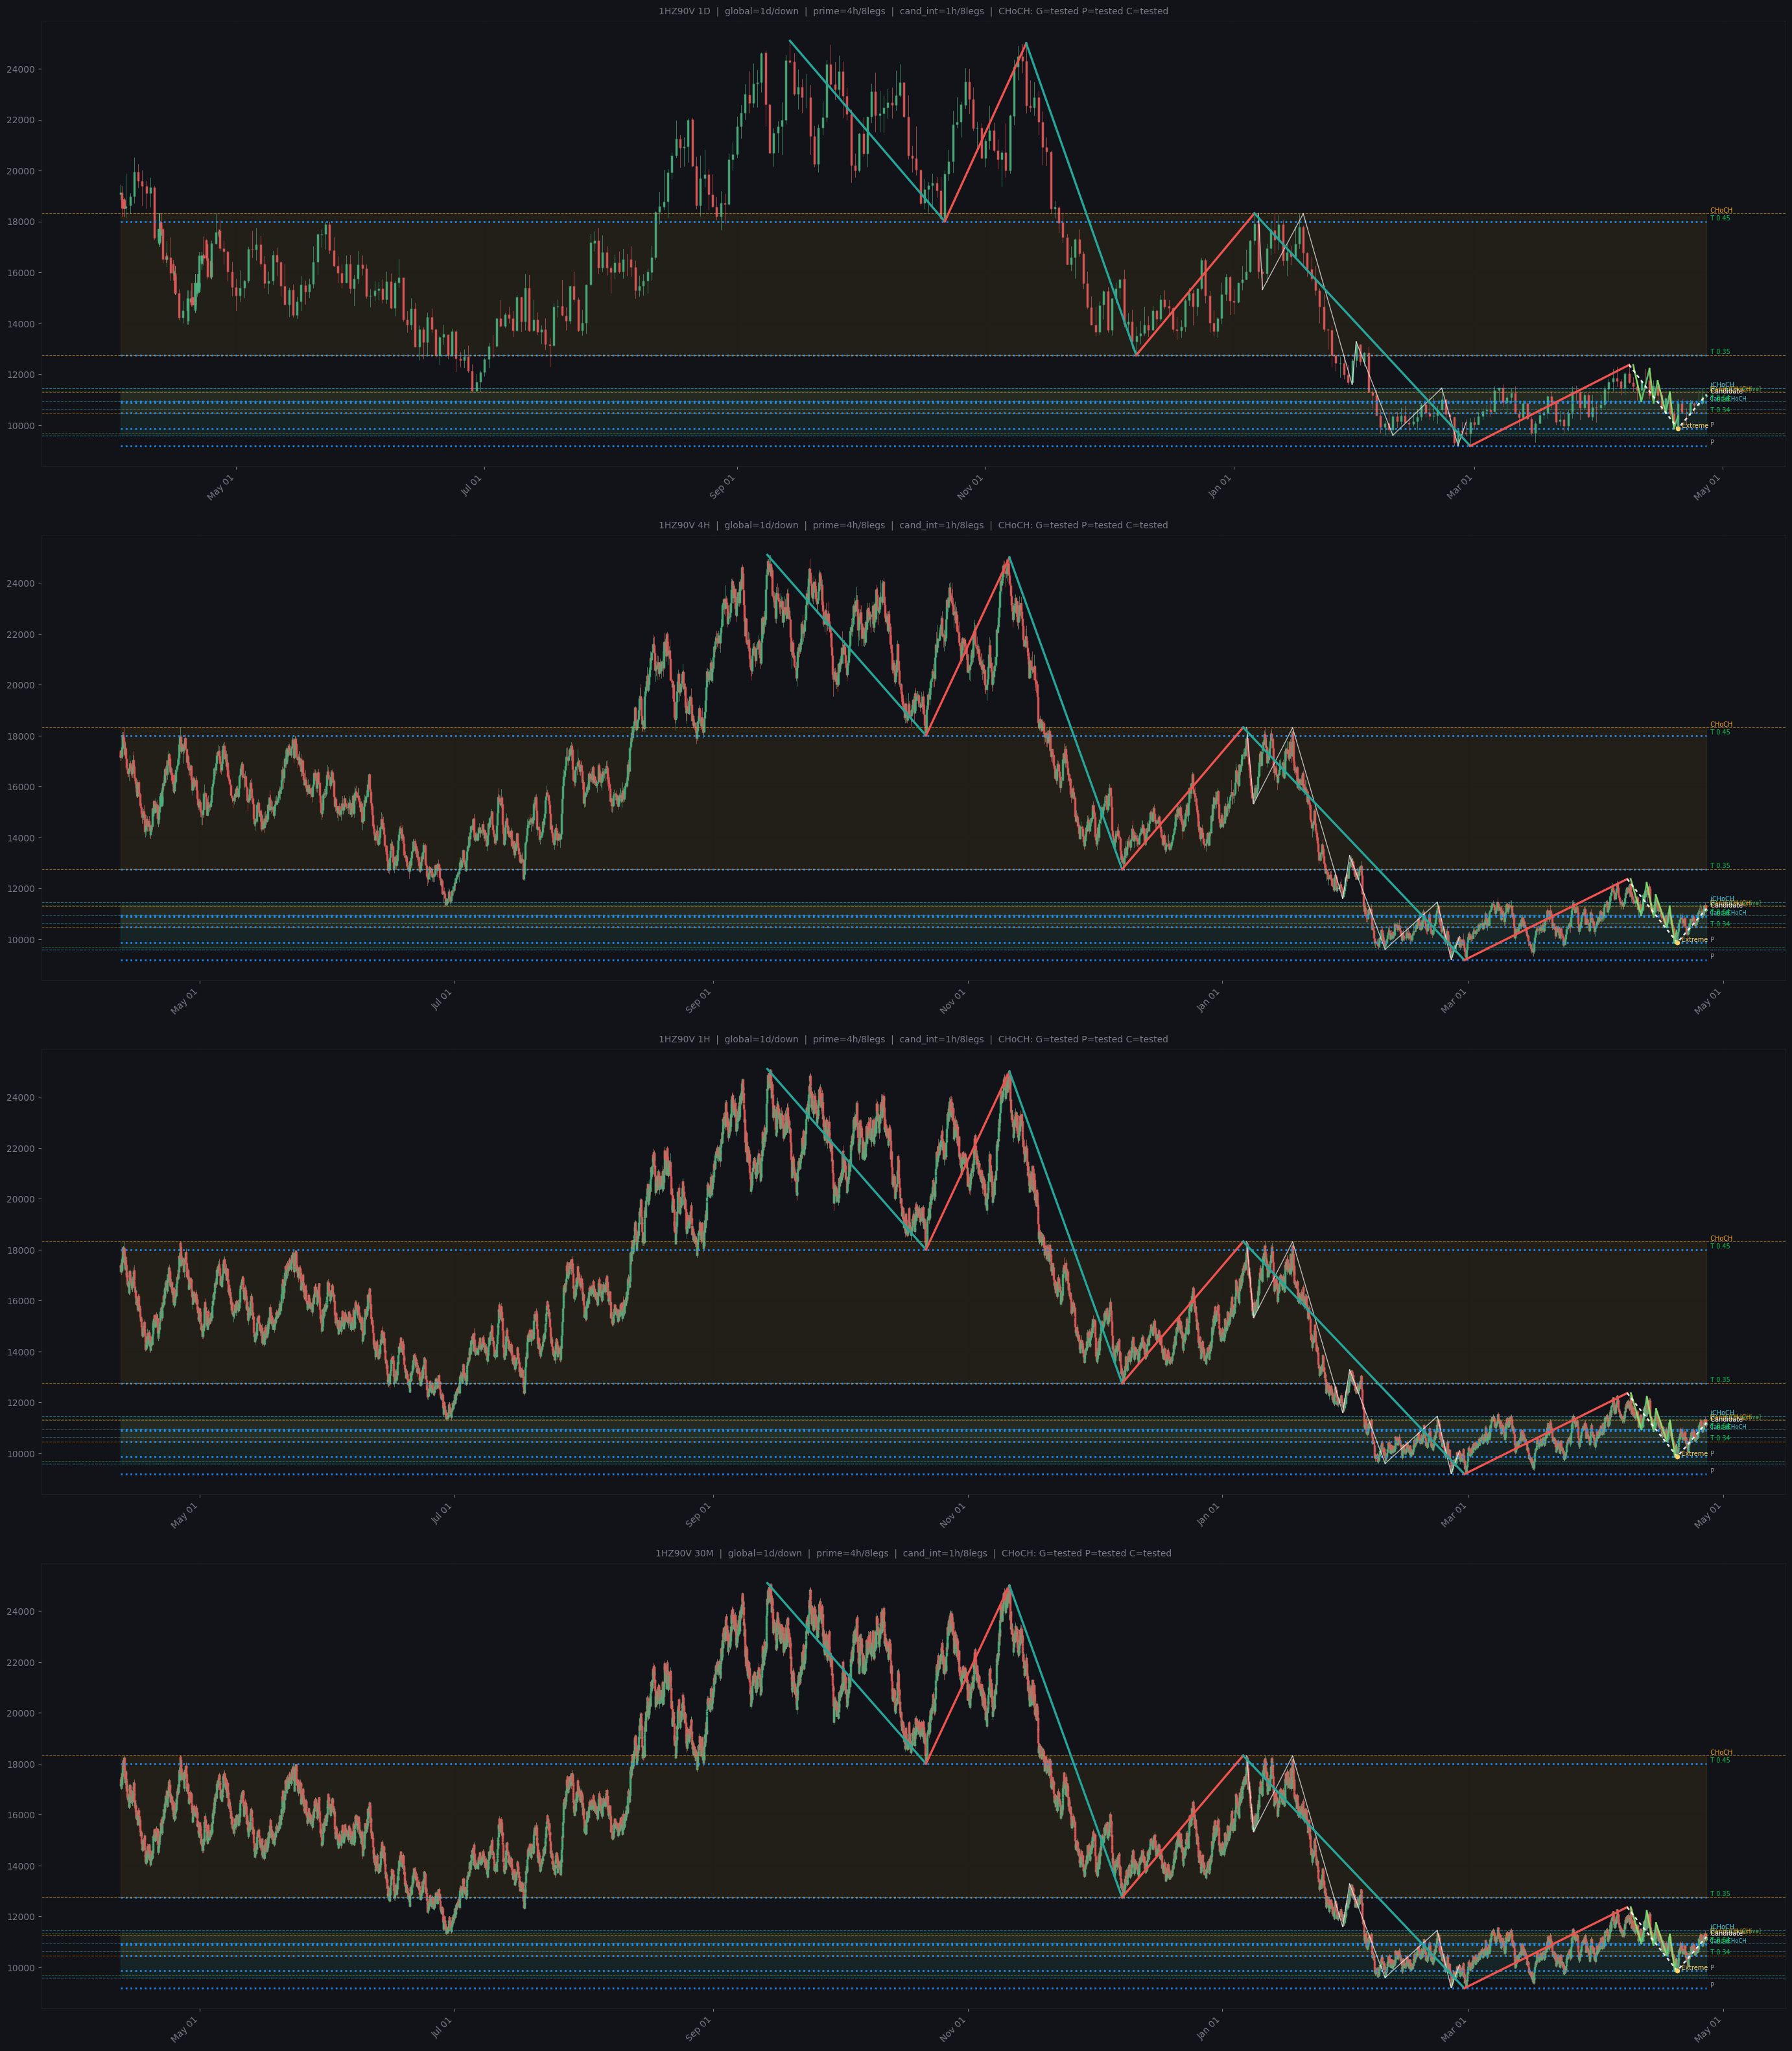

In [31]:
# ============================================================
# CELL 6: CROSS-TIMEFRAME PROJECTION PLOTTING
# Same canonical overlays drawn on every DISPLAY_TIMEFRAMES panel.
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─── Drawing primitives ───────────────────────────────────────────────────────

def _style_axis(ax):
    ax.set_facecolor(COLORS["bg"])
    ax.tick_params(colors=COLORS["text"])
    ax.spines[:].set_color(COLORS["grid"])
    ax.grid(alpha=0.1, color=COLORS["grid"])


def _status_label_text(status: str) -> str:
    return {"true": "T", "false": "F", "invalid": "I"}.get(status, "P")


def _status_label_color(status: str) -> str:
    return {"true": COLORS["bos_true"], "false": COLORS["bos_false"]}.get(
        status, COLORS["bos_pending"]
    )


def _draw_candles(ax, candles):
    for c in candles:
        color = COLORS["candle_up"] if float(c.close) >= float(c.open) else COLORS["candle_down"]
        ax.plot([c.timestamp, c.timestamp], [float(c.low), float(c.high)],
                color=color, linewidth=0.6, alpha=0.8)
        ax.plot([c.timestamp, c.timestamp], [float(c.open), float(c.close)],
                color=color, linewidth=2.5, alpha=0.9, solid_capstyle="butt")


def _project_endpoint(source_candles, leg_idx, display_candles):
    """Convert a source-TF leg endpoint index to nearest display-TF timestamp."""
    if not source_candles or leg_idx is None or leg_idx >= len(source_candles):
        return None
    return _nearest_ts(display_candles, source_candles[leg_idx].timestamp)


def _draw_projected_legs(ax, source_candles, legs, display_candles,
                          impulse_color, retracement_color,
                          linewidth=2.2, alpha=1.0, zorder=4):
    """Draw legs from source_candles projected onto display_candles timestamps."""
    for leg in legs or []:
        if not leg.get("confirmed"):
            continue
        si, ei = leg.get("start_index"), leg.get("end_index")
        if si is None or ei is None:
            continue
        t0 = _project_endpoint(source_candles, si, display_candles)
        t1 = _project_endpoint(source_candles, ei, display_candles)
        if t0 is None or t1 is None:
            continue
        color = impulse_color if leg["type"] == "impulse" else retracement_color
        ax.plot([t0, t1], [leg["start_price"], leg["end_price"]],
                color=color, linewidth=linewidth, alpha=alpha, zorder=zorder)


def _draw_horizontal_band(ax, t0, t1, lower, upper, fill_color,
                           fill_alpha=0.07, line_alpha=0.55,
                           linewidth=0.8, linestyle="dashed", zorder=1):
    ax.fill_between([t0, t1], lower, upper,
                    alpha=fill_alpha, color=fill_color, zorder=zorder)
    ax.axhline(upper, color=fill_color, linewidth=linewidth, linestyle=linestyle, alpha=line_alpha)
    ax.axhline(lower, color=fill_color, linewidth=linewidth, linestyle=linestyle, alpha=line_alpha)


def _draw_bos_levels(ax, t0, t1, bos_levels):
    for bos in bos_levels or []:
        price = bos.get("price")
        if price is None:
            continue
        status = bos.get("classification", "pending")
        ratio  = bos.get("retracement_ratio")
        ax.plot([t0, t1], [price, price],
                color=COLORS["bos_draw"], linewidth=2.0, linestyle="dotted", alpha=0.9, zorder=2)
        suffix = f" {ratio:.2f}" if isinstance(ratio, (int, float)) else ""
        ax.text(t1, price, f"  {_status_label_text(status)}{suffix}",
                color=_status_label_color(status), fontsize=7, va="bottom", zorder=5)


# ─── Canonical overlay renderer ───────────────────────────────────────────────

def draw_canonical_on_panel(ax, display_candles, canonical, display_tf: str):
    """Draw all canonical layers onto ax using display_candles as the canvas."""
    if not display_candles:
        return

    t0 = display_candles[0].timestamp
    t1 = display_candles[-1].timestamp

    _draw_candles(ax, display_candles)

    # ── GLOBAL: legs + BOS + CHoCH zone ──────────────────────────────────────
    if SHOW_GLOBAL:
        g_analysis = canonical["global_analysis"]
        g_candles  = canonical["global_candles"]
        g_result   = g_analysis["result"]

        _draw_projected_legs(
            ax, g_candles, g_result.get("legs", []), display_candles,
            impulse_color=COLORS["global_imp"], retracement_color=COLORS["global_ret"],
            linewidth=2.4, alpha=1.0, zorder=4,
        )
        _draw_bos_levels(ax, t0, t1, g_analysis.get("global_bos_levels", []))

        gz = g_analysis.get("global_choch_zone")
        if gz:
            _draw_horizontal_band(ax, t0, t1,
                                   gz["lower_boundary"], gz["upper_boundary"],
                                   fill_color=COLORS["amber"], fill_alpha=0.08, zorder=1)
            ax.text(t1, gz["upper_boundary"], "  CHoCH", color=COLORS["amber"],
                    fontsize=7, va="bottom")

        # Walker depth zones — each labelled with its CHoCH state
        if SHOW_WALKER:
            ws = g_analysis.get("walker_state") or {}
            _wst_map = {item["depth"]: item for item in (LAYER_STATES.get("walker") or [])}
            for lvl in ws.get("levels", []):
                depth = lvl.get("depth", 0)
                if depth > 3:
                    continue
                zone = lvl.get("choch_zone") or {}
                lo   = zone.get("lower_boundary")
                hi   = zone.get("upper_boundary")
                if lo is None or hi is None:
                    continue
                color  = DEPTH_COLORS.get(depth, COLORS["depth_1"])
                wstate = _wst_map.get(depth, {}).get("choch_state", "")
                label  = f"  D{depth} CHoCH [{wstate}]" if wstate else f"  D{depth} CHoCH"
                _draw_horizontal_band(ax, t0, t1, lo, hi, fill_color=color,
                                       fill_alpha=0.05, line_alpha=0.38,
                                       linewidth=0.7, zorder=1)
                ax.text(t1, hi, label, color=color, fontsize=6, va="bottom")

    # ── PRIME INTERNAL: legs (white dotted) + iCHoCH zone (teal) ─────────────
    if SHOW_PRIME:
        p_analysis = canonical["prime_analysis"]
        if p_analysis:
            p_candles = p_analysis["candles"]
            p_result  = p_analysis["result"]
            _draw_projected_legs(
                ax, p_candles, p_result.get("legs", []), display_candles,
                impulse_color=COLORS["prime_leg"], retracement_color=COLORS["prime_leg"],
                linewidth=1.0, alpha=0.70, zorder=3,
            )
            iz = p_analysis.get("ichoch_zone") or global_analysis.get("ichoch_zone")
        else:
            iz = global_analysis.get("ichoch_zone")

        if iz:
            _draw_horizontal_band(ax, t0, t1,
                                   iz["lower_boundary"], iz["upper_boundary"],
                                   fill_color=COLORS["ichoch"],
                                   fill_alpha=0.06, line_alpha=0.50, zorder=1)
            ax.text(t1, iz["upper_boundary"], "  iCHoCH",
                    color=COLORS["ichoch"], fontsize=7, va="bottom")

    # ── CANDIDATE: anchor + internal legs + CHoCH / iCHoCH zones ─────────────
    if SHOW_CANDIDATE:
        cand = canonical["candidate"]
        if cand:
            ts_start   = _nearest_ts(display_candles, cand["start_ts"])
            ts_extreme = _nearest_ts(display_candles, cand["extreme_ts"])
            ts_current = _nearest_ts(display_candles, cand["current_ts"])

            if ts_start and ts_extreme and ts_current:
                ax.plot(
                    [ts_start, ts_extreme, ts_current],
                    [cand["start_price"], cand["extreme_price"], cand["current_price"]],
                    color=COLORS["candidate_line"], linewidth=1.8,
                    linestyle=(0, (2, 2)), alpha=0.9, zorder=7,
                )
                ax.scatter([ts_extreme], [cand["extreme_price"]],
                           color=COLORS["candidate_extreme"], s=20, zorder=8)
                cand_label = "  Cand BOS" if cand.get("structure_broken") else "  Candidate"
                ax.text(ts_current, cand["current_price"], cand_label,
                        color=COLORS["candidate_line"], fontsize=7, va="bottom", zorder=8)
                ax.text(ts_extreme, cand["extreme_price"], "  Extreme",
                        color=COLORS["candidate_extreme"], fontsize=7, va="bottom", zorder=8)

            cand_int = cand.get("selected_internal")
            if cand_int:
                ci_candles = cand_int["candles"]
                ci_result  = cand_int["result"]

                # Candidate internal legs (green tones)
                _draw_projected_legs(
                    ax, ci_candles, ci_result.get("legs", []), display_candles,
                    impulse_color=COLORS["candidate_imp"],
                    retracement_color=COLORS["candidate_ret"],
                    linewidth=1.9, alpha=0.9, zorder=5,
                )

                # Candidate CHoCH zone (orange)
                cz = cand_int.get("global_choch_zone")
                if cz:
                    _draw_horizontal_band(ax, t0, t1,
                                           cz["lower_boundary"], cz["upper_boundary"],
                                           fill_color=COLORS["cand_choch"],
                                           fill_alpha=0.06, line_alpha=0.45, zorder=1)
                    ax.text(t1, cz["upper_boundary"], "  Cand CHoCH",
                            color=COLORS["cand_choch"], fontsize=7, va="bottom")

                # Candidate iCHoCH zone (teal, slightly more transparent)
                ci_iz = cand_int.get("ichoch_zone")
                if ci_iz:
                    _draw_horizontal_band(ax, t0, t1,
                                           ci_iz["lower_boundary"], ci_iz["upper_boundary"],
                                           fill_color=COLORS["ichoch"],
                                           fill_alpha=0.04, line_alpha=0.32, zorder=1)
                    ax.text(t1, ci_iz["upper_boundary"], "  Cand iCHoCH",
                            color=COLORS["ichoch"], fontsize=6, va="bottom")

                # Candidate BOS levels
                _draw_bos_levels(ax, t0, t1, cand_int.get("global_bos_levels", []))


# ─── Build and render panels ───────────────────────────────────────────────────

_panels = [tf for tf in DISPLAY_TIMEFRAMES if tf in candle_data]
_n      = len(_panels)

fig, axes = plt.subplots(_n, 1, figsize=(28, 8 * _n), facecolor=COLORS["bg"])
if _n == 1:
    axes = [axes]

for ax, tf in zip(axes, _panels):
    _style_axis(ax)
    draw_canonical_on_panel(ax, candle_data[tf], CANONICAL, display_tf=tf)

    _g_choch_st = global_analysis["layer_state"]["choch_state"]
    _p_choch_st = prime_analysis["layer_state"]["choch_state"] if prime_analysis else "n/a"
    _c_choch_st = (
        candidate["selected_internal"]["layer_state"]["choch_state"]
        if candidate and candidate.get("selected_internal") else "n/a"
    )
    title_parts = [
        f"{SYMBOL} {tf.upper()}",
        f"global={GLOBAL_TF}/{global_result['trend']}",
        f"prime={PRIME_TF}/{prime_leg_count}legs",
        f"cand_int={CANDIDATE_TF}/"
        f"{candidate['selected_internal_leg_count'] or 0 if candidate else 0}legs",
        f"CHoCH: G={_g_choch_st} P={_p_choch_st} C={_c_choch_st}",
    ]
    ax.set_title("  |  ".join(title_parts), color=COLORS["text"], fontsize=10, pad=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", color=COLORS["text"])

plt.tight_layout(pad=2.0)
_out = ROOT / "sandbox" / "plots" / f"{SYMBOL}_ui_parity_final.png"
_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(_out, dpi=130, bbox_inches="tight", facecolor=COLORS["bg"])
print(f"Chart saved: {_out.name}")
plt.show()

  RETRACEMENT PENETRATION METRICS   1HZ90V
Definition: penetration_pct = retracement_length / preceding_impulse_length * 100

  GLOBAL  pairs=3
    #1: imp(243->281) ret(281->301) pen=98.61%
    #2: imp(301->328) ret(328->357) pen=45.47%
    #3: imp(357->410) ret(410->449) pen=34.84%  [PRIME]

  PRIME  pairs=4
    #1: imp(5->15) ret(15->88) pen=99.50%
    #2: imp(88->160) ret(160->170) pen=25.11%
    #3: imp(170->221) ret(221->296) pen=50.35%
    #4: imp(296->316) ret(316->328) pen=40.40%  [PRIME]

  CANDIDATE_TREND  pairs=0
    (no confirmed impulse->retracement pairs)

  CANDIDATE_INTERNAL  pairs=4
    #1: imp(21->82) ret(82->113) pen=89.35%
    #2: imp(113->151) ret(151->166) pen=64.49%
    #3: imp(166->228) ret(228->246) pen=64.19%
    #4: imp(246->274) ret(274->283) pen=33.72%  [PRIME]

Chart saved: 1HZ90V_ui_parity_penetration.png


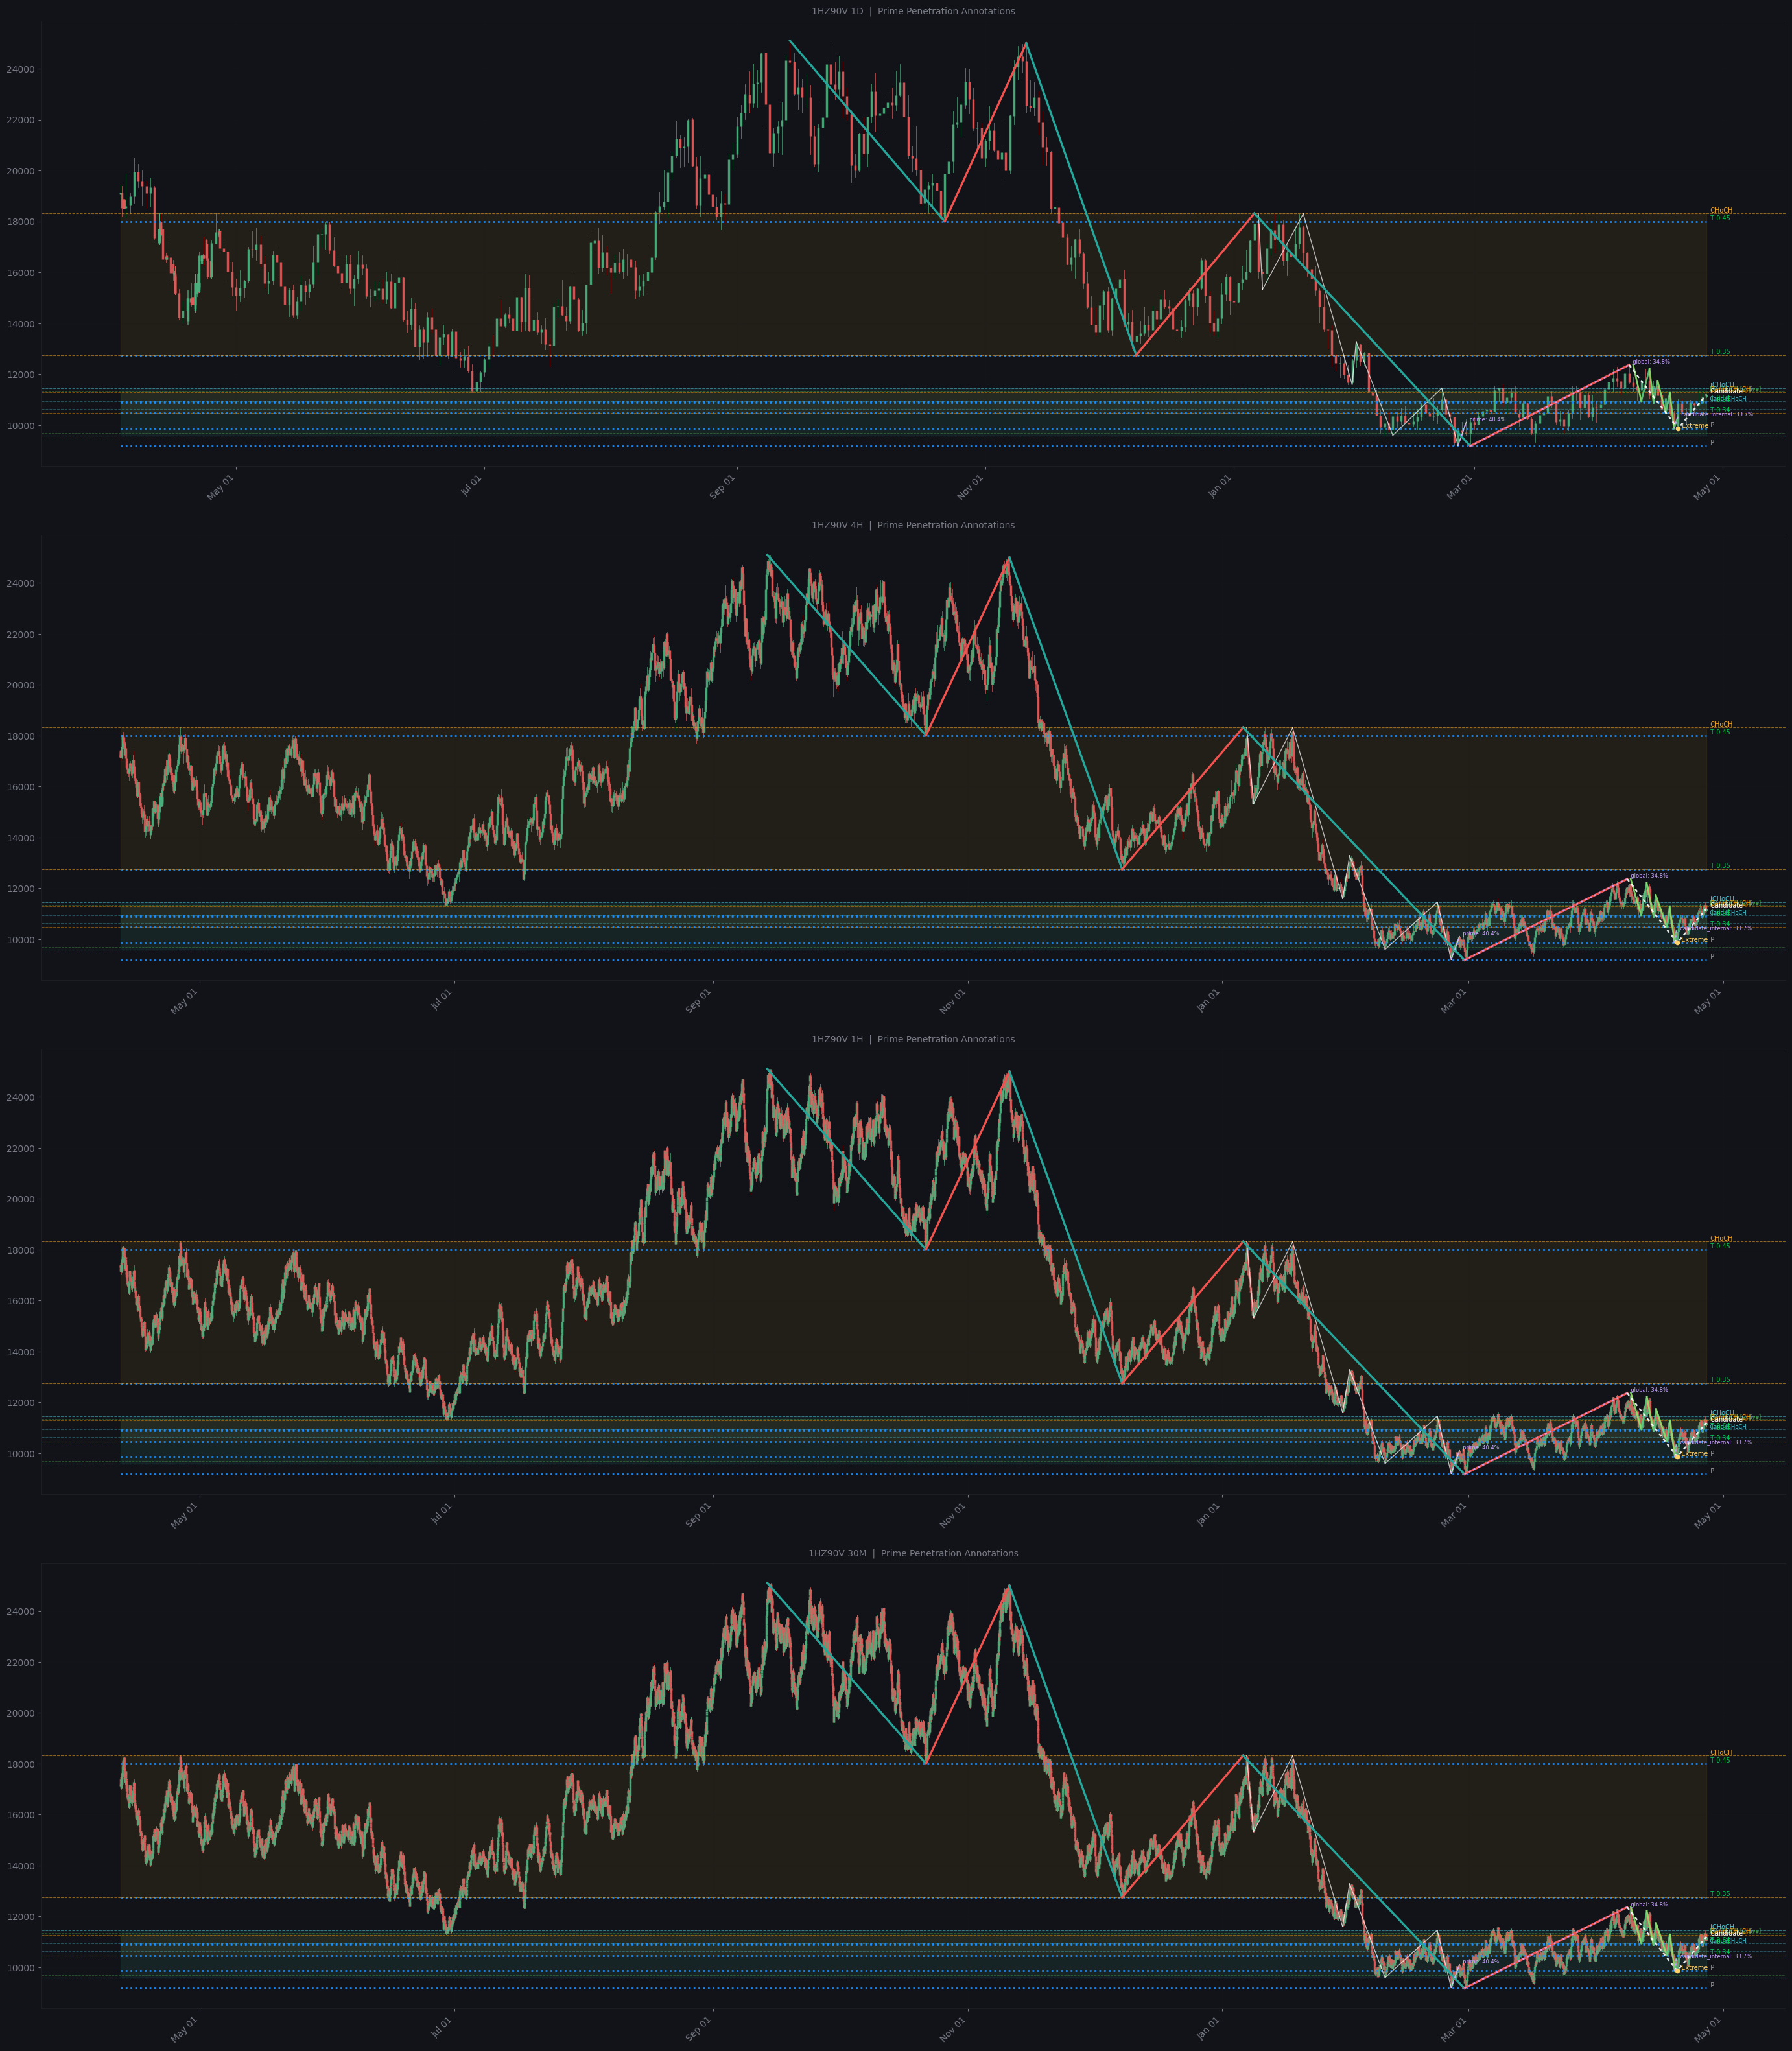

In [32]:
# ============================================================
# CELL 8: PENETRATION METRICS + PRIME ANNOTATIONS
# Computes retracement penetration for ALL confirmed impulse->retracement pairs,
# keeps one prime pair per layer for chart annotation (to avoid clutter).
# ============================================================

PENETRATION_COLOR = "#C8A2FF"  # light purple


def _confirmed_impulse_retracement_pairs(analysis: dict | None) -> list:
    """Return all confirmed retracements paired to their preceding confirmed impulse."""
    if not analysis:
        return []

    result = analysis.get("result") or {}
    legs = result.get("legs") or []
    pairs = []

    for i, leg in enumerate(legs):
        if leg.get("type") != "retracement" or not leg.get("confirmed"):
            continue

        prev_impulse = None
        for j in range(i - 1, -1, -1):
            p = legs[j]
            if p.get("type") == "impulse" and p.get("confirmed"):
                prev_impulse = p
                break

        if not prev_impulse:
            continue

        imp_len = abs(float(prev_impulse.get("end_price", 0.0)) - float(prev_impulse.get("start_price", 0.0)))
        ret_len = abs(float(leg.get("end_price", 0.0)) - float(leg.get("start_price", 0.0)))
        pen_pct = (ret_len / imp_len * 100.0) if imp_len > 0 else None

        pairs.append({
            "impulse_start_index": int(prev_impulse.get("start_index", -1)),
            "impulse_end_index": int(prev_impulse.get("end_index", -1)),
            "impulse_start_price": float(prev_impulse.get("start_price", 0.0)),
            "impulse_end_price": float(prev_impulse.get("end_price", 0.0)),
            "retracement_start_index": int(leg.get("start_index", -1)),
            "retracement_end_index": int(leg.get("end_index", -1)),
            "retracement_start_price": float(leg.get("start_price", 0.0)),
            "retracement_end_price": float(leg.get("end_price", 0.0)),
            "impulse_length": imp_len,
            "retracement_length": ret_len,
            "penetration_pct": pen_pct,
        })

    return pairs


def _compute_candidate_trend_analysis() -> dict | None:
    """Candidate-trend layer analysis over global candidate start->current window."""
    if not candidate:
        return None

    si = int(candidate.get("start_idx", -1))
    ci = int(candidate.get("current_idx", -1))
    if si < 0 or ci < 0 or ci <= si:
        return None

    window = global_candles[si: ci + 1]
    if len(window) < 10:
        return None

    return _analyze_structure_window(window, SYMBOL, run_walker=False)


def _build_penetration_by_layer() -> dict:
    candidate_trend_analysis = _compute_candidate_trend_analysis()

    layer_analyses = {
        "global": global_analysis,
        "prime": prime_analysis,
        "candidate_trend": candidate_trend_analysis,
        "candidate_internal": (
            candidate.get("selected_internal") if candidate and candidate.get("selected_internal") else None
        ),
    }

    out = {}
    for layer_name, analysis in layer_analyses.items():
        all_pairs = _confirmed_impulse_retracement_pairs(analysis)
        prime_pair = all_pairs[-1] if all_pairs else None
        out[layer_name] = {
            "analysis": analysis,
            "all_pairs": all_pairs,
            "prime_pair": prime_pair,
            "pair_count": len(all_pairs),
        }

    return out


# Compute once and store for downstream signal/scoring consumers.
PENETRATION_BY_LAYER = _build_penetration_by_layer()
CANONICAL["penetration_by_layer"] = PENETRATION_BY_LAYER

# Expose prime penetration in layer states for quick signal usage.
for _lname in ("global", "prime", "candidate_internal"):
    _entry = PENETRATION_BY_LAYER.get(_lname) or {}
    _prime = _entry.get("prime_pair")
    _pct = _prime.get("penetration_pct") if _prime else None
    if LAYER_STATES.get(_lname):
        LAYER_STATES[_lname]["prime_penetration_pct"] = _pct


# ---- Console output: all confirmed pairs + clearly marked prime pair ----
print("=" * 78)
print(f"  RETRACEMENT PENETRATION METRICS   {SYMBOL}")
print("=" * 78)
print("Definition: penetration_pct = retracement_length / preceding_impulse_length * 100")

for layer_name in ["global", "prime", "candidate_trend", "candidate_internal"]:
    layer = PENETRATION_BY_LAYER.get(layer_name) or {}
    pairs = layer.get("all_pairs") or []
    prime = layer.get("prime_pair")

    print(f"\n  {layer_name.upper()}  pairs={len(pairs)}")
    if not pairs:
        print("    (no confirmed impulse->retracement pairs)")
        continue

    for idx, pair in enumerate(pairs, start=1):
        mark = "  [PRIME]" if pair is prime else ""
        pct = pair.get("penetration_pct")
        pct_text = f"{pct:.2f}%" if isinstance(pct, (int, float)) else "n/a"
        print(
            f"    #{idx}: imp({pair['impulse_start_index']}->{pair['impulse_end_index']}) "
            f"ret({pair['retracement_start_index']}->{pair['retracement_end_index']}) "
            f"pen={pct_text}{mark}"
        )


# ---- Prime-only annotation lines on chart (to avoid clutter) ----

def _draw_prime_penetration_annotations(ax, display_candles, canonical: dict):
    pbl = canonical.get("penetration_by_layer") or {}

    for layer_name in ["global", "prime", "candidate_trend", "candidate_internal"]:
        entry = pbl.get(layer_name) or {}
        prime_pair = entry.get("prime_pair")
        analysis = entry.get("analysis")
        if not prime_pair or not analysis:
            continue

        source_candles = analysis.get("candles") or []
        imp_end_idx = prime_pair.get("impulse_end_index")
        ret_end_idx = prime_pair.get("retracement_end_index")
        if imp_end_idx is None or ret_end_idx is None:
            continue

        if int(imp_end_idx) < 0 or int(ret_end_idx) < 0:
            continue

        t0 = _project_endpoint(source_candles, int(imp_end_idx), display_candles)
        t1 = _project_endpoint(source_candles, int(ret_end_idx), display_candles)
        if t0 is None or t1 is None:
            continue

        y0 = float(prime_pair.get("impulse_end_price", 0.0))
        y1 = float(prime_pair.get("retracement_end_price", 0.0))
        pct = prime_pair.get("penetration_pct")
        if pct is None:
            continue

        ax.plot(
            [t0, t1],
            [y0, y1],
            color=PENETRATION_COLOR,
            linewidth=1.5,
            linestyle=(0, (1.5, 2.2)),
            alpha=0.95,
            zorder=9,
        )
        ax.text(
            t1,
            y1,
            f"  {layer_name}: {pct:.1f}%",
            color=PENETRATION_COLOR,
            fontsize=6,
            va="bottom",
            zorder=10,
        )


# Render an additional chart image with prime-only penetration overlays.
_panels = [tf for tf in DISPLAY_TIMEFRAMES if tf in candle_data]
_n = len(_panels)

fig, axes = plt.subplots(_n, 1, figsize=(28, 8 * _n), facecolor=COLORS["bg"])
if _n == 1:
    axes = [axes]

for ax, tf in zip(axes, _panels):
    _style_axis(ax)
    draw_canonical_on_panel(ax, candle_data[tf], CANONICAL, display_tf=tf)
    _draw_prime_penetration_annotations(ax, candle_data[tf], CANONICAL)

    ax.set_title(
        f"{SYMBOL} {tf.upper()}  |  Prime Penetration Annotations",
        color=COLORS["text"],
        fontsize=10,
        pad=8,
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", color=COLORS["text"])

plt.tight_layout(pad=2.0)
_pen_out = ROOT / "sandbox" / "plots" / f"{SYMBOL}_ui_parity_penetration.png"
_pen_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(_pen_out, dpi=130, bbox_inches="tight", facecolor=COLORS["bg"])
print(f"\nChart saved: {_pen_out.name}")
plt.show()

In [33]:
# ============================================================
# CELL 7: DIFF — sandbox vs live  (run before pushing)
# ============================================================
import subprocess

_diff = subprocess.run(
    [sys.executable, str(ROOT / "sandbox" / "diff_tool.py")],
    capture_output=True, text=True, cwd=str(ROOT),
)
print(_diff.stdout)
if _diff.stderr:
    print("STDERR:", _diff.stderr[:200])

IKENGA SANDBOX vs LIVE DIFF

trend_id.py  [CHANGED]
  + _passes_filters  [NEW in sandbox]
  ~ compute_internal_structure  [MODIFIED]
  ~ identify_trend  [MODIFIED]

global_structure.py  [unchanged]
  (no changes)

structural_walker.py  [CHANGED]
  + _as_utc_timestamp  [NEW in sandbox]
  + _build_internal_candidate  [NEW in sandbox]
  + _clip_candles_to_range  [NEW in sandbox]
  + _confirmed_leg_count_for_deepening  [NEW in sandbox]
  + _first_confirmed_impulse  [NEW in sandbox]
  + _first_impulse_duration_seconds  [NEW in sandbox]
  + _nearest_global_index_from_timestamp  [NEW in sandbox]
  + _pick_deepening_candidate  [NEW in sandbox]
  + _select_internal_structure_for_range  [NEW in sandbox]
  ~ _walk_level  [MODIFIED]
  ~ walk_structure  [MODIFIED]

choch_zone.py  [unchanged]
  (no changes)

structure_levels.py  [CHANGED]
  + annotate_internal_bos_classifications  [NEW in sandbox]
  + classify_bos_events  [NEW in sandbox]
  + collapse_false_break_impulses  [NEW in sandbox]
  + extra